--- IMAGE ---
tensor type: torch.float32
shape: torch.Size([3, 512, 512])
min: -1.0000
max: 0.8588

--- MASK ---
shape: torch.Size([512, 512])
type: torch.int64
unique classes: [0, 1, 3, 7, 8, 9, 10, 11]


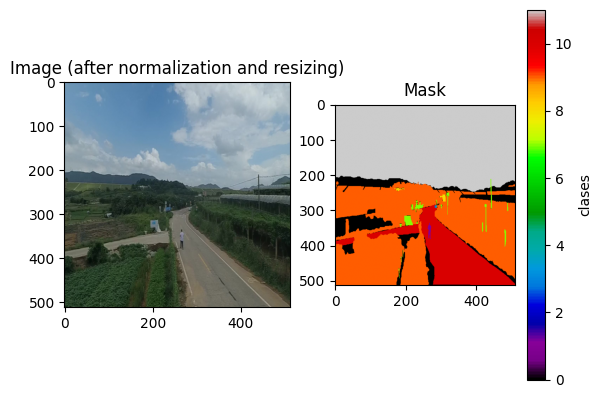

In [7]:
import matplotlib.pyplot as plt
from src.datasets.aeroscapes import AeroScapesDataset

data = AeroScapesDataset(data_dir="test_data/aeroscapes", size=(512, 512))

image, label_dict = data[0]
mask = label_dict["mask"]

print("--- IMAGE ---")
print(f"tensor type: {image.dtype}")
print(f"shape: {image.shape}") # should be [3, 512, 512]
print(f"min: {image.min():.4f}") # should be close to -1.0
print(f"max: {image.max():.4f}") # should be close to 1.0

print("\n--- MASK ---")
print(f"shape: {mask.shape}") # should be [512, 512]
print(f"type: {mask.dtype}")    # should be torch.int64 (Long)
print(f"unique classes: {mask.unique().tolist()}")

# To display the image, we need to reverse the normalization (from the range [-1, 1] to [0, 1]) + reordering the dimensions for matplot
img_display = (image.permute(1, 2, 0) + 1) / 2

plt.figure()
plt.subplot(1, 2, 1)
plt.imshow(img_display)
plt.title("Image (after normalization and resizing)")

plt.subplot(1, 2, 2)
plt.imshow(mask.numpy(), cmap='nipy_spectral')
plt.colorbar(label="clases")
plt.title("Mask")
    
plt.show()